## **📚 Google Drive Connection**

In [5]:
from google.colab import drive
drive.mount("/gdrive")
current_dir = "/gdrive/My Drive/[2025-2026] AN2DL/Challenge 1"
%cd $current_dir

Mounted at /gdrive
/gdrive/My Drive/[2025-2026] AN2DL/Challenge 1


## **⚙️ Libraries Import**

In [6]:
# Set seed for reproducibility
SEED = 42

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import for Attention
import torch.nn as nn
import torch.nn.functional as F

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
# from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import TensorDataset, DataLoader
logs_dir = "tensorboard"
!pkill -f tensorboard
%load_ext tensorboard
!mkdir -p models

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import copy
import shutil
from itertools import product
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

PyTorch version: 2.8.0+cu126
Device: cuda


## ⏳ **Data Loading**

In [7]:
X_train = pd.read_csv('pirate_pain_train.csv')
y_train = pd.read_csv('pirate_pain_train_labels.csv')

X_test = pd.read_csv('pirate_pain_test.csv')

## 🔎 **Exploration and Data Analysis**

In [8]:
# Merge the dataframes to associate labels to data
df = pd.merge(X_train, y_train, on = "sample_index")

# Remove rows with any missing values
df.dropna(axis=0, how='any', inplace=True)

# Print the shape of the DataFrame
print(f"DataFrame shape: {df.shape}")

# Display the first 10 rows of the Data Frame
df.head()

DataFrame shape: (105760, 41)


,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,n_hands,n_eyes,joint_00,...,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30,label
0,0,0,2,0,2,1,two,two,two,1.094705,...,1.945042e-06,0.000004,1.153299e-05,0.000004,0.017592,0.013508,0.026798,0.027815,0.5,no_pain
1,0,1,2,2,2,2,two,two,two,1.135183,...,6.765107e-07,0.000006,4.643774e-08,0.000000,0.013352,0.000000,0.013377,0.013716,0.5,no_pain
2,0,2,2,0,2,2,two,two,two,1.080745,...,1.698525e-07,0.000001,2.424536e-06,0.000003,0.016225,0.008110,0.024097,0.023105,0.5,no_pain
3,0,3,2,2,2,2,two,two,two,0.938017,...,5.511079e-07,0.000002,5.432416e-08,0.000000,0.011832,0.007450,0.028613,0.024648,0.5,no_pain
4,0,4,2,2,2,2,two,two,two,1.090185,...,1.735459e-07,0.000002,5.825366e-08,0.000007,0.005360,0.002532,0.033026,0.025328,0.5,no_pain


In [9]:
# Creation of the test set
df_test = X_test

# Print the shape of the DataFrame
print(f"DataFrame shape: {df_test.shape}")

df_test.head()

DataFrame shape: (211840, 40)


,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,n_hands,n_eyes,joint_00,...,joint_21,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30
0,0,0,2,2,2,2,two,two,two,0.842535,...,0.000003,0.000004,0.000003,0.000003,0.000068,0.019372,0.066324,0.022228,0.013576,0.5
1,0,1,2,2,2,2,two,two,two,0.898836,...,0.000003,0.000004,0.000004,0.000003,0.000029,0.069747,0.080417,0.023650,0.038793,0.5
2,0,2,2,2,2,2,two,two,two,0.957765,...,0.000006,0.000004,0.000009,0.000004,0.000008,0.054968,0.058811,0.027023,0.054202,0.5
3,0,3,1,2,2,2,two,two,two,0.832596,...,0.000005,0.000004,0.000003,0.000004,0.000015,0.048695,0.047128,0.016151,0.024983,0.5
4,0,4,2,2,2,0,two,two,two,0.805971,...,0.000006,0.000004,0.000003,0.000003,0.000008,0.019762,0.031116,0.015618,0.017931,0.5


we noticed that some features have a std very low --> remove them

In [10]:
filter = 1e-2


keep_always = ['label', 'n_legs', 'n_hands', 'n_eyes']

# filter numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
columns_to_keep = df[numeric_cols].loc[:, df[numeric_cols].std() >= filter].columns.tolist()

# Keep original order
final_columns = [col for col in df.columns if col in columns_to_keep or col in keep_always]
df = df[final_columns]

In [11]:


keep_always = ['n_legs', 'n_hands', 'n_eyes']

numeric_cols = df.select_dtypes(include=[np.number]).columns
columns_to_keep = df[numeric_cols].loc[:, df[numeric_cols].std() >= filter].columns.tolist()

final_columns = [col for col in df.columns if col in columns_to_keep or col in keep_always]

#take a column if it is in final_columns && df_test.columns (that way we can exclude 'label')
df_test= df_test[[col for col in final_columns if col in df_test.columns]]

In [12]:
# Display a concise summary of the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105760 entries, 0 to 105759
Data columns (total 27 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   sample_index   105760 non-null  int64  
 1   time           105760 non-null  int64  
 2   pain_survey_1  105760 non-null  int64  
 3   pain_survey_2  105760 non-null  int64  
 4   pain_survey_3  105760 non-null  int64  
 5   pain_survey_4  105760 non-null  int64  
 6   n_legs         105760 non-null  object 
 7   n_hands        105760 non-null  object 
 8   n_eyes         105760 non-null  object 
 9   joint_00       105760 non-null  float64
 10  joint_01       105760 non-null  float64
 11  joint_02       105760 non-null  float64
 12  joint_03       105760 non-null  float64
 13  joint_04       105760 non-null  float64
 14  joint_05       105760 non-null  float64
 15  joint_06       105760 non-null  float64
 16  joint_07       105760 non-null  float64
 17  joint_08       105760 non-nul

In [13]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211840 entries, 0 to 211839
Data columns (total 26 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   sample_index   211840 non-null  int64  
 1   time           211840 non-null  int64  
 2   pain_survey_1  211840 non-null  int64  
 3   pain_survey_2  211840 non-null  int64  
 4   pain_survey_3  211840 non-null  int64  
 5   pain_survey_4  211840 non-null  int64  
 6   n_legs         211840 non-null  object 
 7   n_hands        211840 non-null  object 
 8   n_eyes         211840 non-null  object 
 9   joint_00       211840 non-null  float64
 10  joint_01       211840 non-null  float64
 11  joint_02       211840 non-null  float64
 12  joint_03       211840 non-null  float64
 13  joint_04       211840 non-null  float64
 14  joint_05       211840 non-null  float64
 15  joint_06       211840 non-null  float64
 16  joint_07       211840 non-null  float64
 17  joint_08       211840 non-nul

the columns "n_legs", "n_hands", "n_eyes" heve type=object --> convert them in type=bool

"n_legs" --> "two legs"

In [14]:
def convert_to_bool(value):
  if value == "two":
    return 1
  else:
    return 0

In [15]:
df['n_legs'] = df['n_legs'].apply(convert_to_bool)
df['n_hands'] = df['n_hands'].apply(convert_to_bool)
df['n_eyes'] = df['n_eyes'].apply(convert_to_bool)

In [16]:
df_test['n_legs'] = df_test['n_legs'].apply(convert_to_bool)
df_test['n_hands'] = df_test['n_hands'].apply(convert_to_bool)
df_test['n_eyes'] = df_test['n_eyes'].apply(convert_to_bool)

convert everything into float32

In [17]:
# Convert all columns whose data type is float64/bool/int64 to float32 data type
for col in df.columns:
  if (df[col].dtype == 'float64') or (df[col].dtype == 'bool') or (df[col].dtype == 'int64'):
    df[col] = df[col].astype(np.float32)

# Display updated DataFrame info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105760 entries, 0 to 105759
Data columns (total 27 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   sample_index   105760 non-null  float32
 1   time           105760 non-null  float32
 2   pain_survey_1  105760 non-null  float32
 3   pain_survey_2  105760 non-null  float32
 4   pain_survey_3  105760 non-null  float32
 5   pain_survey_4  105760 non-null  float32
 6   n_legs         105760 non-null  float32
 7   n_hands        105760 non-null  float32
 8   n_eyes         105760 non-null  float32
 9   joint_00       105760 non-null  float32
 10  joint_01       105760 non-null  float32
 11  joint_02       105760 non-null  float32
 12  joint_03       105760 non-null  float32
 13  joint_04       105760 non-null  float32
 14  joint_05       105760 non-null  float32
 15  joint_06       105760 non-null  float32
 16  joint_07       105760 non-null  float32
 17  joint_08       105760 non-nul

In [18]:
for col in df_test.columns:
  if (df_test[col].dtype == 'float64') or (df_test[col].dtype == 'bool') or (df_test[col].dtype == 'int64'):
    df_test[col] = df_test[col].astype(np.float32)

# Display updated DataFrame info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105760 entries, 0 to 105759
Data columns (total 27 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   sample_index   105760 non-null  float32
 1   time           105760 non-null  float32
 2   pain_survey_1  105760 non-null  float32
 3   pain_survey_2  105760 non-null  float32
 4   pain_survey_3  105760 non-null  float32
 5   pain_survey_4  105760 non-null  float32
 6   n_legs         105760 non-null  float32
 7   n_hands        105760 non-null  float32
 8   n_eyes         105760 non-null  float32
 9   joint_00       105760 non-null  float32
 10  joint_01       105760 non-null  float32
 11  joint_02       105760 non-null  float32
 12  joint_03       105760 non-null  float32
 13  joint_04       105760 non-null  float32
 14  joint_05       105760 non-null  float32
 15  joint_06       105760 non-null  float32
 16  joint_07       105760 non-null  float32
 17  joint_08       105760 non-nul

a bit of plotting

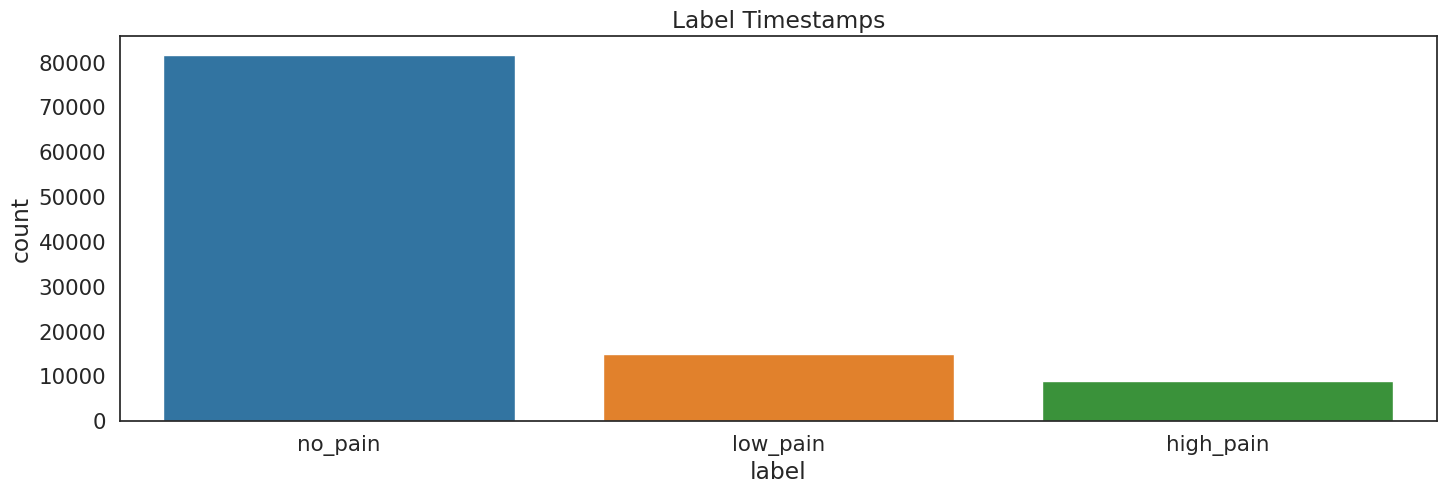

In [19]:
# Visualise the count of timestamps for each label pain
plt.figure(figsize=(17, 5))
sns.countplot(
    x='label',
    data=df,
    order=df['label'].value_counts().index,
    palette='tab10'
)

# Set the title of the plot
plt.title('Label Timestamps')

# Display the plot
plt.show()

In [20]:
def inspect_pain(sample_id, df, surveys=['pain_survey_1','pain_survey_2','pain_survey_3','pain_survey_4'], max_timesteps=180):
    # Filter by sample_index
    data = df[df['sample_index'] == sample_id].iloc[:max_timesteps]

    # Select only the columns corresponding to surveys
    pain_data = data[surveys]

    # Plot
    axes = pain_data.plot(subplots=True, figsize=(12, 8), marker='o', title=f"Pain over time for Sample {sample_id}")

    for ax in axes:
        ax.set_xlabel("Timestep")
        ax.set_ylabel("Pain value")
        ax.legend(loc='upper right')

    plt.tight_layout(pad=3.0)
    plt.show()

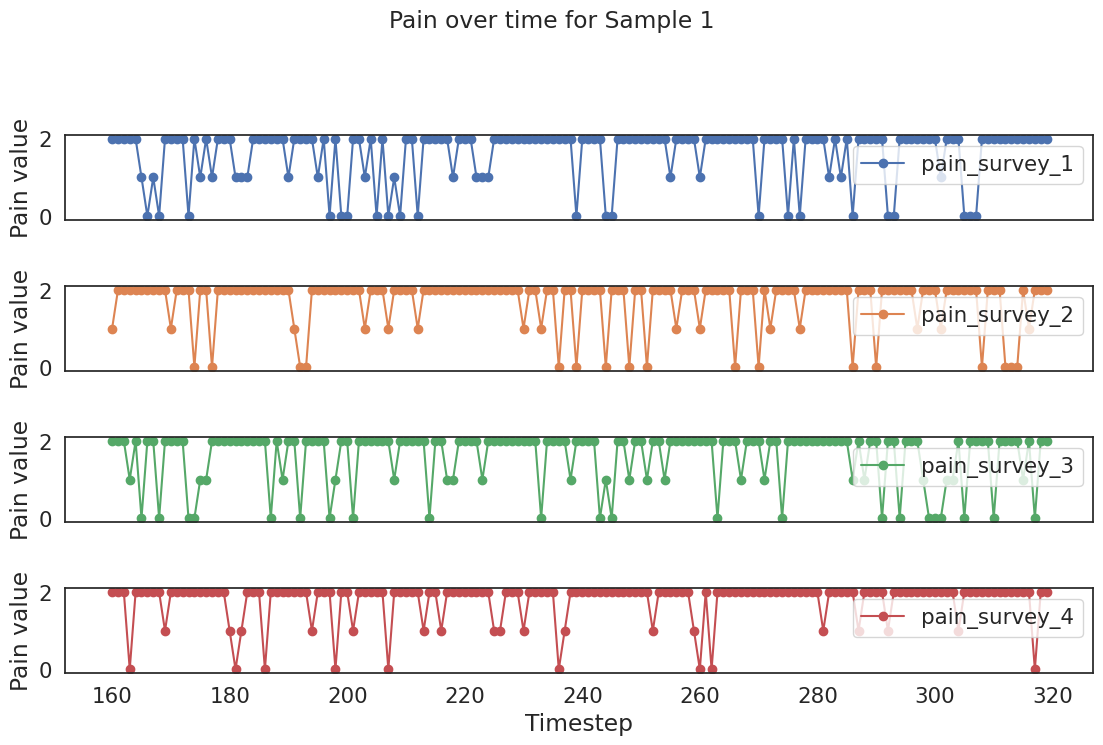

In [21]:
inspect_pain(1, df)

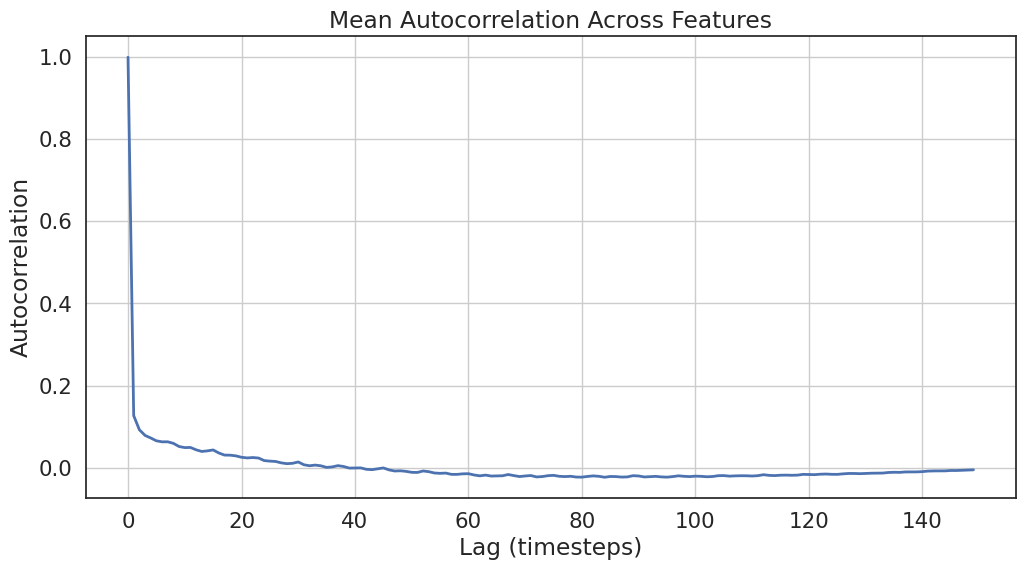

['pain_survey_1',
 'pain_survey_2',
 'pain_survey_3',
 'pain_survey_4',
 'n_legs',
 'n_hands',
 'n_eyes',
 'joint_00',
 'joint_01',
 'joint_02',
 'joint_03',
 'joint_04',
 'joint_05',
 'joint_06',
 'joint_07',
 'joint_08',
 'joint_09',
 'joint_10',
 'joint_11',
 'joint_12',
 'joint_26',
 'joint_27',
 'joint_28',
 'joint_29']

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Select only numeric features (exclude sample_index, time, label)
exclude_cols = ['sample_index', 'time', 'label']
features = [c for c in df.columns if c not in exclude_cols]

# Maximum lag we test (in timesteps)
MAX_LAG = 150

# Container for all autocorrelations
ac_values = []

# Compute autocorrelation per subject, per feature
for sample_id in df['sample_index'].unique():
    df_sub = df[df['sample_index'] == sample_id]

    for f in features:
        x = df_sub[f].values
        x = x - np.mean(x)  # zero-mean for stability

        # Skip se troppo corto
        if len(x) < MAX_LAG:
            continue

        # Skip se costante
        if np.std(x) < 1e-6:
            continue

        # compute autocorrelation with numpy
        corr = np.correlate(x, x, mode='full')
        corr = corr[corr.size // 2:]  # take positive lags only
        corr = corr[:MAX_LAG] / corr[0]  # normalize

        ac_values.append(corr)

# Convert to numpy array
ac_values = np.array(ac_values)

# Average autocorrelation across subjects and features
mean_ac = ac_values.mean(axis=0)

# Plot
plt.figure(figsize=(12,6))
plt.plot(mean_ac, linewidth=2)
plt.title("Mean Autocorrelation Across Features")
plt.xlabel("Lag (timesteps)")
plt.ylabel("Autocorrelation")
plt.grid(True)
plt.show()

features


## 🔄 **Data Preprocessing**

### **Split**

In [23]:
unique_subjects = df['sample_index'].unique()
n_subjects = len(unique_subjects)

# Check uniformity of timestamps per subject
df['sample_index'].value_counts().describe()

n_samples_per_subject = df['sample_index'].value_counts()[0]

print(n_subjects, n_samples_per_subject)

661 160


split--> 80% train set, 20% validation set

In [24]:
# Reproducibility of shuffling
random.seed(SEED)
random.shuffle(unique_subjects)

# Number of subjects for validation
N_VAL_SUBJECTS = n_subjects // 5

# Number of subjects for train
n_train_subjects = len(unique_subjects) - N_VAL_SUBJECTS

# Split shuffled subject indexes into training and validation
train_subjects = unique_subjects[:n_train_subjects]
val_subjects = unique_subjects[n_train_subjects:n_train_subjects + N_VAL_SUBJECTS]

# Split DataFrames into training and validation sets
df_train = df[df['sample_index'].isin(train_subjects)]
df_val = df[df['sample_index'].isin(val_subjects)]

# Print shapes of training and validation
print(f'Training set shape: {df_train.shape}')
print(f'Validation set shape: {df_val.shape}')


Training set shape: (84640, 27)
Validation set shape: (21120, 27)


###**Dictionaries + label mapping**

In [25]:
# Initialise a dictionary to count occurrences of each activity in the training set
training_labels = {
    'no_pain': 0,
    'low_pain': 0,
    'high_pain': 0,
}

# Count occurrences of each activity for unique IDs in the training set
for id in df_train['sample_index'].unique():
    label = df_train[df_train['sample_index'] == id]['label'].values[0]
    training_labels[label] += 1

# Print the distribution of training labels
print('Training labels:', training_labels)

Training labels: {'no_pain': 409, 'low_pain': 75, 'high_pain': 45}


In [26]:
# Initialise a dictionary to count occurrences of each activity in the training set
val_labels = {
    'no_pain': 0,
    'low_pain': 0,
    'high_pain': 0,
}

# Count occurrences of each activity for unique IDs in the training set
for id in df_val['sample_index'].unique():
    label = df_val[df_val['sample_index'] == id]['label'].values[0]
    val_labels[label] += 1

# Print the distribution of training labels
print('Validation labels:', val_labels)

Validation labels: {'no_pain': 102, 'low_pain': 19, 'high_pain': 11}


In [27]:
# Define a mapping of activity names to integer labels
label_mapping = {
    'no_pain': 0,
    'low_pain': 1,
    'high_pain': 2,
}

# Map activity names to integers in the training set
df_train['label'] = df_train['label'].map(label_mapping)

# Map activity names to integers in the validation set
df_val['label'] = df_val['label'].map(label_mapping)

### **Normalization**

min/max normalization of columns "joint_n"

we normalize just the columns with continious data, there's no point in normalizing the other ones






In [29]:
exclude_cols = ['sample_index', 'time', 'label','pain_survey_1','pain_survey_2','pain_survey_3','pain_survey_4']
feature_cols = [col for col in df.columns if col not in exclude_cols]

mins = df_train.select_dtypes(include=np.number).drop(columns=exclude_cols).min()
maxs = df_train.select_dtypes(include=np.number).drop(columns=exclude_cols).max()

for column in df_train.select_dtypes(include=np.number).drop(columns=exclude_cols).columns:
  df_train[column] = (df_train[column] - mins[column]) / (maxs[column] - mins[column])
  df_val[column] = (df_val[column] - mins[column]) / (maxs[column] - mins[column])
  df_test[column] = (df_test[column] - mins[column]) / (maxs[column] - mins[column])



### Windowing

In [30]:
WINDOW_SIZE = 30

STRIDE = 15

In [31]:
# Define a function to build sequences from the dataset
def build_sequences(df, window=160, stride=160):
    # Sanity check to ensure the window is divisible by the stride
    assert window % stride == 0

    # Initialise lists to store sequences and their corresponding labels
    dataset = []
    labels = []

    # Iterate over unique samples in the DataFrame
    for id in df['sample_index'].unique():
        # Extract data for the current sample
        temp = df[df['sample_index'] == id][df.columns[2:-1]].values

        # Retrieve the activity label for the current sample
        label = df[df['sample_index'] == id]['label'].values[0]


        # Build feature windows and associate them with labels
        idx = 0
        while idx + window <= len(temp):
            dataset.append(temp[idx:idx + window])
            labels.append(label)
            idx += stride

    # Convert lists to numpy arrays for further processing
    dataset = np.array(dataset)
    labels = np.array(labels)

    return dataset, labels

In [32]:
# Define a function to build sequences from the dataset
def build_sequences_test(df, window=160, stride=160):
    # Sanity check to ensure the window is divisible by the stride
    assert window % stride == 0

    # Initialise lists to store sequences and their corresponding labels
    dataset = []

    # Iterate over unique samples in the DataFrame
    for id in df['sample_index'].unique():
        # Extract data for the current sample
        temp = df[df['sample_index'] == id][df.columns[2:]].values

        # Build feature windows and associate them with labels
        idx = 0
        while idx + window <= len(temp):
            dataset.append(temp[idx:idx + window])
            idx += stride

    # Convert lists to numpy arrays for further processing
    dataset = np.array(dataset)

    return dataset

In [33]:
# Generate sequences and labels for the training set
X_train, y_train = build_sequences(df_train, WINDOW_SIZE, STRIDE)

# Generate sequences and labels for the validation set
X_val, y_val = build_sequences(df_val, WINDOW_SIZE, STRIDE)

# Generate sequences and labels for the training set
X_re_train, y_re_train = build_sequences(df_train, WINDOW_SIZE, STRIDE)

# Generate sequences and labels for the validation set
X_re_val, y_re_val = build_sequences(df_val, WINDOW_SIZE, STRIDE)

# Generate sequences and labels for the test set
X_test = build_sequences_test(df_test, WINDOW_SIZE, STRIDE)

# Print the shapes of the generated datasets and their labels
X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape

((4761, 30, 24), (4761,), (1188, 30, 24), (1188,), (11916, 30, 24))

In [34]:
# Define the input shape based on the training data
input_shape = X_train.shape[1:]

# Define the input shape based on the training data
input_re_shape = X_re_train.shape[1:]

# Define the number of classes based on the categorical labels
num_classes = len(np.unique(y_train))

In [35]:
# Convert numpy arrays to PyTorch datasets (pairs features with labels)
train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
val_ds   = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val))
test_ds   = TensorDataset(torch.from_numpy(X_test))

# Convert numpy arrays to PyTorch datasets (pairs features with labels)
re_train_ds = TensorDataset(torch.from_numpy(X_re_train), torch.from_numpy(y_re_train))
re_val_ds   = TensorDataset(torch.from_numpy(X_re_val), torch.from_numpy(y_re_val))

In [36]:
# Define the batch size, which is the number of samples in each batch
BATCH_SIZE = 64

In [37]:
def make_loader(ds, batch_size, shuffle, drop_last):
    # Determine optimal number of worker processes for data loading
    cpu_cores = os.cpu_count() or 2
    num_workers = max(2, min(4, cpu_cores))

    # Create DataLoader with performance optimizations
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
        pin_memory=True,  # Faster GPU transfer
        pin_memory_device="cuda" if torch.cuda.is_available() else "",
        prefetch_factor=4,  # Load 4 batches ahead
    )

In [38]:
# Create data loaders with different settings for each phase
train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader   = make_loader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader  = make_loader(test_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

# Create data loaders with different settings for each phase
re_train_loader = make_loader(re_train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
re_val_loader   = make_loader(re_val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

In [39]:
# Get one batch from the training data loader
for xb, yb in train_loader:
    print("Features batch shape:", xb.shape)
    print("Labels batch shape:", yb.shape)
    break # Stop after getting one batch

Features batch shape: torch.Size([64, 30, 24])
Labels batch shape: torch.Size([64])


## 🛠️ **Model Building**

In [40]:
def recurrent_summary(model, input_size):
    """
    Custom summary function that emulates torchinfo's output while correctly
    counting parameters for RNN/GRU/LSTM layers.

    This function is designed for models whose direct children are
    nn.Linear, nn.RNN, nn.GRU, or nn.LSTM layers.

    Args:
        model (nn.Module): The model to analyze.
        input_size (tuple): Shape of the input tensor (e.g., (seq_len, features)).
    """

    # Dictionary to store output shapes captured by forward hooks
    output_shapes = {}
    # List to track hook handles for later removal
    hooks = []

    def get_hook(name):
        """Factory function to create a forward hook for a specific module."""
        def hook(module, input, output):
            # Handle RNN layer outputs (returns a tuple)
            if isinstance(output, tuple):
                # output[0]: all hidden states with shape (batch, seq_len, hidden*directions)
                shape1 = list(output[0].shape)
                shape1[0] = -1  # Replace batch dimension with -1

                # output[1]: final hidden state h_n (or tuple (h_n, c_n) for LSTM)
                if isinstance(output[1], tuple):  # LSTM case: (h_n, c_n)
                    shape2 = list(output[1][0].shape)  # Extract h_n only
                else:  # RNN/GRU case: h_n only
                    shape2 = list(output[1].shape)

                # Replace batch dimension (middle position) with -1
                shape2[1] = -1

                output_shapes[name] = f"[{shape1}, {shape2}]"

            # Handle standard layer outputs (e.g., Linear)
            else:
                shape = list(output.shape)
                shape[0] = -1  # Replace batch dimension with -1
                output_shapes[name] = f"{shape}"
        return hook

    # 1. Determine the device where model parameters reside
    try:
        device = next(model.parameters()).device
    except StopIteration:
        device = torch.device("cpu")  # Fallback for models without parameters

    # 2. Create a dummy input tensor with batch_size=1
    dummy_input = torch.randn(1, *input_size).to(device)

    # 3. Register forward hooks on target layers
    # Iterate through direct children of the model (e.g., self.rnn, self.classifier)
    for name, module in model.named_children():
        if isinstance(module, (nn.Linear, nn.RNN, nn.GRU, nn.LSTM)):
            # Register the hook and store its handle for cleanup
            hook_handle = module.register_forward_hook(get_hook(name))
            hooks.append(hook_handle)

    # 4. Execute a dummy forward pass in evaluation mode
    model.eval()
    with torch.no_grad():
        try:
            model(dummy_input)
        except Exception as e:
            print(f"Error during dummy forward pass: {e}")
            # Clean up hooks even if an error occurs
            for h in hooks:
                h.remove()
            return

    # 5. Remove all registered hooks
    for h in hooks:
        h.remove()

    # --- 6. Print the summary table ---

    print("-" * 79)
    # Column headers
    print(f"{'Layer (type)':<25} {'Output Shape':<28} {'Param #':<18}")
    print("=" * 79)

    total_params = 0
    total_trainable_params = 0

    # Iterate through modules again to collect and display parameter information
    for name, module in model.named_children():
        if name in output_shapes:
            # Count total and trainable parameters for this module
            module_params = sum(p.numel() for p in module.parameters())
            trainable_params = sum(p.numel() for p in module.parameters() if p.requires_grad)

            total_params += module_params
            total_trainable_params += trainable_params

            # Format strings for display
            layer_name = f"{name} ({type(module).__name__})"
            output_shape_str = str(output_shapes[name])
            params_str = f"{trainable_params:,}"

            print(f"{layer_name:<25} {output_shape_str:<28} {params_str:<15}")

    print("=" * 79)
    print(f"Total params: {total_params:,}")
    print(f"Trainable params: {total_trainable_params:,}")
    print(f"Non-trainable params: {total_params - total_trainable_params:,}")
    print("-" * 79)

Attention

In [41]:
class SimpleAttention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attn_weights = nn.Linear(hidden_size, 1)
    def forward(self, rnn_out):
        # rnn_out: (batch, seq_len, hidden_size * directions)
        scores = self.attn_weights(rnn_out)         # (batch, seq_len, 1)
        weights = torch.softmax(scores, dim=1)      # (batch, seq_len, 1)
        context = torch.sum(weights * rnn_out, dim=1) # (batch, hidden_size * directions)
        return context, weights

Focal loss

In [42]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):

        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        # Cross entropy per-sample
        ce_loss = F.cross_entropy(logits, targets, weight=self.alpha, reduction='none')

        # pt = correct class probability
        pt = torch.exp(-ce_loss)

        # focal loss
        focal_loss = (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [43]:
class RecurrentClassifier(nn.Module):
    """
    Generic RNN classifier (RNN, LSTM, GRU).
    Uses the last hidden state for classification.
    """
    def __init__(
            self,
            input_size,
            hidden_size,
            num_layers,
            num_classes,
            rnn_type='GRU',        # 'RNN', 'LSTM', or 'GRU'
            bidirectional=True,
            dropout_rate=0.3
            ):
        super().__init__()

        self.rnn_type = rnn_type
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.bidirectional = bidirectional

        # Map string name to PyTorch RNN class
        rnn_map = {
            'RNN': nn.RNN,
            'LSTM': nn.LSTM,
            'GRU': nn.GRU
        }

        if rnn_type not in rnn_map:
            raise ValueError("rnn_type must be 'RNN', 'LSTM', or 'GRU'")

        rnn_module = rnn_map[rnn_type]

        # Dropout is only applied between layers (if num_layers > 1)
        dropout_val = dropout_rate if num_layers > 1 else 0

        # Create the recurrent layer
        self.rnn = rnn_module(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,       # Input shape: (batch, seq_len, features)
            bidirectional=bidirectional,
            dropout=dropout_val
        )

        # Calculate input size for the final classifier
        if self.bidirectional:
            classifier_input_size = hidden_size * 2 # Concat fwd + bwd
        else:
            classifier_input_size = hidden_size

        # Final classification layer
        # Final classification layer
        #self.classifier = nn.Linear(classifier_input_size, num_classes)
        self.attention = SimpleAttention(classifier_input_size)
        self.classifier = nn.Linear(classifier_input_size, num_classes)

    def forward(self, x):
        """
        x shape: (batch_size, seq_length, input_size)
        """

        # rnn_out shape: (batch_size, seq_len, hidden_size * num_directions)
        rnn_out, hidden = self.rnn(x)

        # LSTM returns (h_n, c_n), we only need h_n
        if self.rnn_type == 'LSTM':
            hidden = hidden[0]

        # hidden shape: (num_layers * num_directions, batch_size, hidden_size)

        if self.bidirectional:
            # Reshape to (num_layers, 2, batch_size, hidden_size)
            hidden = hidden.view(self.num_layers, 2, -1, self.hidden_size)

            # Concat last fwd (hidden[-1, 0, ...]) and bwd (hidden[-1, 1, ...])
            # Final shape: (batch_size, hidden_size * 2)
            hidden_to_classify = torch.cat([hidden[-1, 0, :, :], hidden[-1, 1, :, :]], dim=1)
        else:
            # Take the last layer's hidden state
            # Final shape: (batch_size, hidden_size)
            hidden_to_classify = hidden[-1]

        # Get logits
        # logits = self.classifier(hidden_to_classify)
        context, attn_weights = self.attention(rnn_out)
        logits = self.classifier(context)
        return logits


# Create model and display architecture with parameter count
rnn_model = RecurrentClassifier(
    input_size=input_shape[-1], # Pass the number of features
    hidden_size=128,
    num_layers=2,
    num_classes=num_classes,
    dropout_rate=0.3,
    rnn_type='GRU'
    ).to(device)
recurrent_summary(rnn_model, input_size=input_shape)

-------------------------------------------------------------------------------
Layer (type)              Output Shape                 Param #           
rnn (GRU)                 [[-1, 30, 256], [4, -1, 128]] 414,720        
classifier (Linear)       [-1, 3]                      771            
Total params: 415,491
Trainable params: 415,491
Non-trainable params: 0
-------------------------------------------------------------------------------


## 🧮 **Network and Training Hyperparameters**

In [44]:
# Training configuration
LEARNING_RATE = 1e-3
EPOCHS = 500
PATIENCE = 50

# Architecture
HIDDEN_LAYERS = 2        # Hidden layers
HIDDEN_SIZE = 128        # Neurons per layer

# Regularisation
DROPOUT_RATE = 0.3         # Dropout probability
L1_LAMBDA = 0            # L1 penalty
L2_LAMBDA = 0.01           # L2 penalty

from sklearn.utils.class_weight import compute_class_weight

classes=np.unique(y_train)
weights=compute_class_weight(class_weight='balanced',classes=classes,y=y_train)
weights=torch.tensor(weights,dtype=torch.float).to(device)

# Set up loss function and optimizer
criterion = FocalLoss(alpha=weights, gamma=2.0)

## 🧠 **Model Training**

In [45]:
# Initialize best model tracking variables
best_model = None
best_performance = float('-inf')

train_one_epoch + gradient clipping

In [46]:
def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device, l1_lambda=0, l2_lambda=0):
    """
    Perform one complete training epoch through the entire training dataset.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): Lambda for L1 regularization
        l2_lambda (float): Lambda for L2 regularization

    Returns:
        tuple: (average_loss, f1 score) - Training loss and f1 score for this epoch
    """
    model.train()  # Set model to training mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Iterate through training batches
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        # Move data to device (GPU/CPU)
        inputs, targets = inputs.to(device), targets.to(device)

        # Clear gradients from previous step
        optimizer.zero_grad(set_to_none=True)

        # Forward pass with mixed precision (if CUDA available)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            logits = model(inputs)
            loss = criterion(logits, targets)

            # Add L1 and L2 regularization
            l1_norm = sum(p.abs().sum() for p in model.parameters())
            l2_norm = sum(p.pow(2).sum() for p in model.parameters())
            loss = loss + l1_lambda * l1_norm + l2_lambda * l2_norm


        # Backward pass with gradient scaling
        scaler.scale(loss).backward()

        # Unscale gradients before clipping
        scaler.unscale_(optimizer)
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        scaler.step(optimizer)
        scaler.update()

        # Accumulate metrics
        running_loss += loss.item() * inputs.size(0)
        predictions = logits.argmax(dim=1)
        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_f1 = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_f1

In [47]:
def validate_one_epoch(model, val_loader, criterion, device):
    """
    Perform one complete validation epoch through the entire validation dataset.

    Args:
        model (nn.Module): The neural network model to evaluate (must be in eval mode)
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        criterion (nn.Module): Loss function used to calculate validation loss
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)

    Returns:
        tuple: (average_loss, accuracy) - Validation loss and accuracy for this epoch

    Note:
        This function automatically sets the model to evaluation mode and disables
        gradient computation for efficiency during validation.
    """
    model.eval()  # Set model to evaluation mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Disable gradient computation for validation
    with torch.no_grad():
        for inputs, targets in val_loader:
            # Move data to device
            inputs, targets = inputs.to(device), targets.to(device)

            # Forward pass with mixed precision (if CUDA available)
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(inputs)
                loss = criterion(logits, targets)

            # Accumulate metrics
            running_loss += loss.item() * inputs.size(0)
            predictions = logits.argmax(dim=1)
            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_accuracy = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_accuracy

In [48]:
def log_metrics_to_tensorboard(writer, epoch, train_loss, train_f1, val_loss, val_f1, model):
    """
    Log training metrics and model parameters to TensorBoard for visualization.

    Args:
        writer (SummaryWriter): TensorBoard SummaryWriter object for logging
        epoch (int): Current epoch number (used as x-axis in TensorBoard plots)
        train_loss (float): Training loss for this epoch
        train_f1 (float): Training f1 score for this epoch
        val_loss (float): Validation loss for this epoch
        val_f1 (float): Validation f1 score for this epoch
        model (nn.Module): The neural network model (for logging weights/gradients)

    Note:
        This function logs scalar metrics (loss/f1 score) and histograms of model
        parameters and gradients, which helps monitor training progress and detect
        issues like vanishing/exploding gradients.
    """
    # Log scalar metrics
    writer.add_scalar('Loss/Training', train_loss, epoch)
    writer.add_scalar('Loss/Validation', val_loss, epoch)
    writer.add_scalar('F1/Training', train_f1, epoch)
    writer.add_scalar('F1/Validation', val_f1, epoch)

    # Log model parameters and gradients
    for name, param in model.named_parameters():
        if param.requires_grad:
            # Check if the tensor is not empty before adding a histogram
            if param.numel() > 0:
                writer.add_histogram(f'{name}/weights', param.data, epoch)
            if param.grad is not None:
                # Check if the gradient tensor is not empty before adding a histogram
                if param.grad.numel() > 0:
                    if param.grad is not None and torch.isfinite(param.grad).all():
                        writer.add_histogram(f'{name}/gradients', param.grad.data, epoch)

In [49]:
def fit(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
        l1_lambda=0, l2_lambda=0, patience=0, evaluation_metric="val_f1", mode='max',
        restore_best_weights=True, writer=None, verbose=10, experiment_name=""):
    """
    Train the neural network model on the training data and validate on the validation data.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        epochs (int): Number of training epochs
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): L1 regularization coefficient (default: 0)
        l2_lambda (float): L2 regularization coefficient (default: 0)
        patience (int): Number of epochs to wait for improvement before early stopping (default: 0)
        evaluation_metric (str): Metric to monitor for early stopping (default: "val_f1")
        mode (str): 'max' for maximizing the metric, 'min' for minimizing (default: 'max')
        restore_best_weights (bool): Whether to restore model weights from best epoch (default: True)
        writer (SummaryWriter, optional): TensorBoard SummaryWriter object for logging (default: None)
        verbose (int, optional): Frequency of printing training progress (default: 10)
        experiment_name (str, optional): Experiment name for saving models (default: "")

    Returns:
        tuple: (model, training_history) - Trained model and metrics history
    """

    # Initialize metrics tracking
    training_history = {
        'train_loss': [], 'val_loss': [],
        'train_f1': [], 'val_f1': []
    }

    # Configure early stopping if patience is set
    if patience > 0:
        patience_counter = 0
        best_metric = float('-inf') if mode == 'max' else float('inf')
        best_epoch = 0

    print(f"Training {epochs} epochs...")

    # Main training loop: iterate through epochs
    for epoch in range(1, epochs + 1):

        # Forward pass through training data, compute gradients, update weights
        train_loss, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device, l1_lambda, l2_lambda
        )

        # Evaluate model on validation data without updating weights
        val_loss, val_f1 = validate_one_epoch(
            model, val_loader, criterion, device
        )

        # Store metrics for plotting and analysis
        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['train_f1'].append(train_f1)
        training_history['val_f1'].append(val_f1)

        # Write metrics to TensorBoard for visualization
        if writer is not None:
            log_metrics_to_tensorboard(
                writer, epoch, train_loss, train_f1, val_loss, val_f1, model
            )

        # Print progress every N epochs or on first epoch
        if verbose > 0:
            if epoch % verbose == 0 or epoch == 1:
                print(f"Epoch {epoch:3d}/{epochs} | "
                    f"Train: Loss={train_loss:.4f}, F1 Score={train_f1:.4f} | "
                    f"Val: Loss={val_loss:.4f}, F1 Score={val_f1:.4f}")

        # Early stopping logic: monitor metric and save best model
        if patience > 0:
            current_metric = training_history[evaluation_metric][-1]
            is_improvement = (current_metric > best_metric) if mode == 'max' else (current_metric < best_metric)

            if is_improvement:
                best_metric = current_metric
                best_epoch = epoch
                torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered after {epoch} epochs.")
                    break

    # Restore best model weights if early stopping was used
    if restore_best_weights and patience > 0:
        model.load_state_dict(torch.load("models/"+experiment_name+'_model.pt'))
        print(f"Best model restored from epoch {best_epoch} with {evaluation_metric} {best_metric:.4f}")

    # Save final model if no early stopping
    if patience == 0:
        torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')

    # Close TensorBoard writer
    if writer is not None:
        writer.close()

    return model, training_history

Create the model

In [50]:
# Create model and display architecture with parameter count
rnn_model = RecurrentClassifier(
    input_size=input_shape[-1], # Pass the number of features
    hidden_size=HIDDEN_SIZE,
    num_layers=HIDDEN_LAYERS,
    num_classes=num_classes,
    dropout_rate=DROPOUT_RATE,
    bidirectional=True,
    rnn_type='GRU'    #RNN, LSTM or GRU
    ).to(device)
recurrent_summary(rnn_model, input_size=input_shape)

# Set up TensorBoard logging and save model architecture
experiment_name = "gru"   #rnn, lstm or gru
writer = SummaryWriter("./"+logs_dir+"/"+experiment_name)
x = torch.randn(1, input_shape[0], input_shape[1]).to(device)
writer.add_graph(rnn_model, x)

# Define optimizer with L2 regularization
optimizer = torch.optim.AdamW(rnn_model.parameters(), lr=LEARNING_RATE, weight_decay=L2_LAMBDA)

# Enable mixed precision training for GPU acceleration
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

-------------------------------------------------------------------------------
Layer (type)              Output Shape                 Param #           
rnn (GRU)                 [[-1, 30, 256], [4, -1, 128]] 414,720        
classifier (Linear)       [-1, 3]                      771            
Total params: 415,491
Trainable params: 415,491
Non-trainable params: 0
-------------------------------------------------------------------------------


In [51]:
%%time
# Train model and track training history
rnn_model, training_history = fit(
    model=rnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    writer=writer,
    verbose=1,
    experiment_name="GRU",
    patience=PATIENCE
    )

# Update best model if current performance is superior
if training_history['val_f1'][-1] > best_performance:
    best_model = rnn_model
    best_performance = training_history['val_f1'][-1]

Training 500 epochs...
Epoch   1/500 | Train: Loss=0.6162, F1 Score=0.1665 | Val: Loss=0.5698, F1 Score=0.0781
Epoch   2/500 | Train: Loss=0.5677, F1 Score=0.2630 | Val: Loss=0.5498, F1 Score=0.0817
Epoch   3/500 | Train: Loss=0.5208, F1 Score=0.2331 | Val: Loss=0.5136, F1 Score=0.2753
Epoch   4/500 | Train: Loss=0.4721, F1 Score=0.2029 | Val: Loss=0.5018, F1 Score=0.2898
Epoch   5/500 | Train: Loss=0.4486, F1 Score=0.3511 | Val: Loss=0.5455, F1 Score=0.4613
Epoch   6/500 | Train: Loss=0.3641, F1 Score=0.5518 | Val: Loss=0.5820, F1 Score=0.5118
Epoch   7/500 | Train: Loss=0.3174, F1 Score=0.6172 | Val: Loss=0.4750, F1 Score=0.4513
Epoch   8/500 | Train: Loss=0.2877, F1 Score=0.5852 | Val: Loss=0.5567, F1 Score=0.6602
Epoch   9/500 | Train: Loss=0.2441, F1 Score=0.6295 | Val: Loss=0.4766, F1 Score=0.5991
Epoch  10/500 | Train: Loss=0.2762, F1 Score=0.6335 | Val: Loss=0.4443, F1 Score=0.7623
Epoch  11/500 | Train: Loss=0.2413, F1 Score=0.6862 | Val: Loss=0.5494, F1 Score=0.4862
Epoch  12

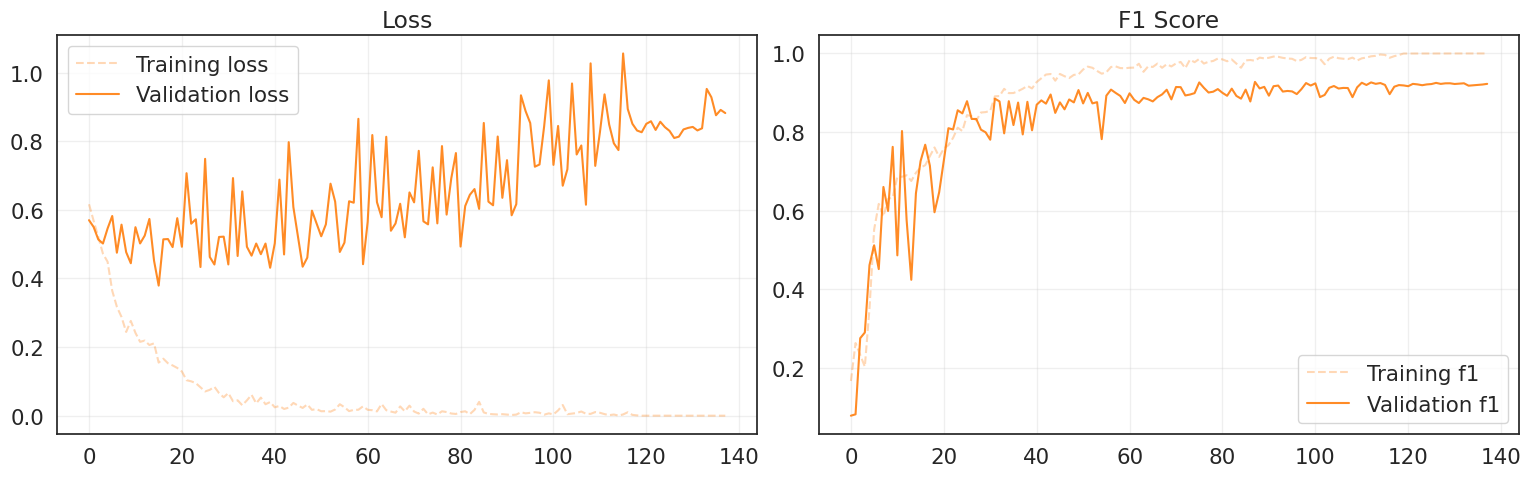

In [52]:
# @title Plot History
# Create a figure with two side-by-side subplots (two columns)
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Plot of training and validation loss on the first axis
ax1.plot(training_history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(training_history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot of training and validation accuracy on the second axis
ax2.plot(training_history['train_f1'], label='Training f1', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(training_history['val_f1'], label='Validation f1', alpha=0.9, color='#ff7f0e')
ax2.set_title('F1 Score')
ax2.legend()
ax2.grid(alpha=0.3)

# Adjust the layout and display the plot
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

Accuracy over the validation set: 0.9285
Precision over the validation set: 0.9286
Recall over the validation set: 0.9285
F1 score over the validation set: 0.9276


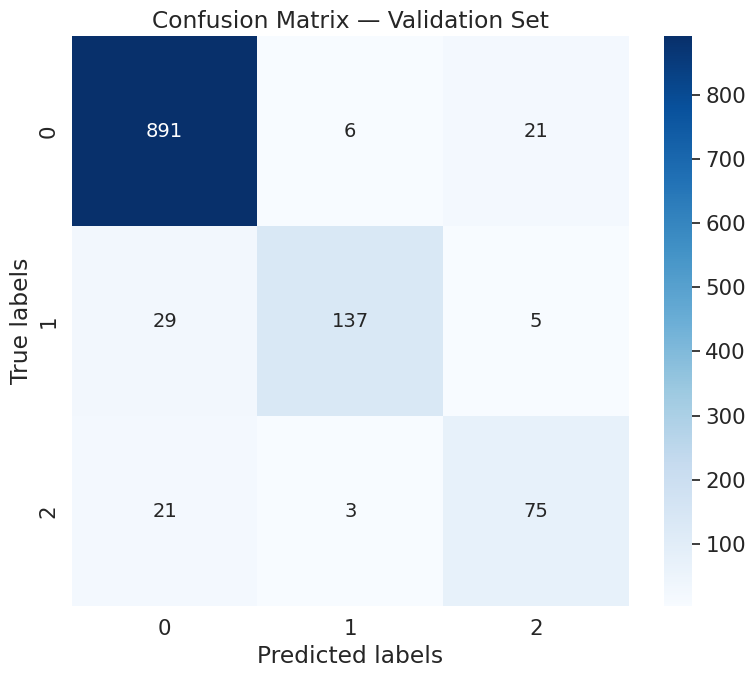

In [53]:
# @title Plot Confusion Matrix
# Collect predictions and ground truth labels
val_preds, val_targets = [], []
with torch.no_grad():  # Disable gradient computation for inference
    for xb, yb in val_loader:
        xb = xb.to(device)

        # Forward pass: get model predictions
        logits = rnn_model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()

        # Store batch results
        val_preds.append(preds)
        val_targets.append(yb.numpy())

# Combine all batches into single arrays
val_preds = np.concatenate(val_preds)
val_targets = np.concatenate(val_targets)

# Calculate overall validation metrics
val_acc = accuracy_score(val_targets, val_preds)
val_prec = precision_score(val_targets, val_preds, average='weighted')
val_rec = recall_score(val_targets, val_preds, average='weighted')
val_f1 = f1_score(val_targets, val_preds, average='weighted')
print(f"Accuracy over the validation set: {val_acc:.4f}")
print(f"Precision over the validation set: {val_prec:.4f}")
print(f"Recall over the validation set: {val_rec:.4f}")
print(f"F1 score over the validation set: {val_f1:.4f}")

# Generate confusion matrix for detailed error analysis
cm = confusion_matrix(val_targets, val_preds)

# Create numeric labels for heatmap annotation
labels = np.array([f"{num}" for num in cm.flatten()]).reshape(cm.shape)

# Visualise confusion matrix
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=labels, fmt='',
            cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix — Validation Set')
plt.tight_layout()
plt.show()

## **⚔️Cross Validation**

In [54]:
# Cross-validation
K = 5                  # Number of splits (5 and 10 are considered good values)
N_VAL_USERS = n_subjects // 5
N_TEST_USERS = n_subjects // 5     # Number of users for validation split

# Training
EPOCHS = 500             # Maximum epochs (increase to improve performance)
PATIENCE = 50            # Early stopping patience (increase to improve performance)
VERBOSE = 10             # Print frequency

# Optimisation
LEARNING_RATE = 1e-3     # Learning rate
BATCH_SIZE = 64         # Batch size
WINDOW_SIZE = 30        # Input window size
STRIDE = 15            # Input stride

# Architecture
HIDDEN_LAYERS = 2        # Hidden layers
HIDDEN_SIZE = 128        # Neurons per layer
RNN_TYPE = 'GRU'         # Type of RNN architecture
BIDIRECTIONAL = True    # Bidirectional RNN

# Regularisation
DROPOUT_RATE = 0.3       # Dropout probability
L1_LAMBDA = 0            # L1 penalty
L2_LAMBDA = 0.01            # L2 penalty

# Training utilities
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
weights = torch.tensor(weights, dtype=torch.float).to(device)

criterion = FocalLoss(alpha=weights, gamma=2.0)
 # meglio no label_smoothing

In [55]:
exclude_cols = ['sample_index', 'time', 'label']
feature_cols = [col for col in df.columns if col not in exclude_cols]

In [56]:
def k_shuffle_split_cross_validation_round_rnn(df, epochs, criterion, device,
                            k, n_val_users, n_test_users, batch_size, hidden_layers, hidden_size, learning_rate, dropout_rate,
                            window_size, stride, rnn_type, bidirectional,
                            l1_lambda=0, l2_lambda=0, patience=0, evaluation_metric="val_f1", mode='max',
                            restore_best_weights=True, writer=None, verbose=10, seed=42, experiment_name=""):
    """
    Perform K-fold shuffle split cross-validation with user-based splitting for time series data.

    Args:
        df: DataFrame with columns ['user_id', 'activity', 'x_axis', 'y_axis', 'z_axis', 'id']
        epochs: Number of training epochs
        criterion: Loss function
        device: torch.device for computation
        k: Number of cross-validation splits
        n_val_users: Number of users for validation set
        n_test_users: Number of users for test set
        batch_size: Batch size for training
        hidden_layers: Number of recurrent layers
        hidden_size: Hidden state dimensionality
        learning_rate: Learning rate for optimizer
        dropout_rate: Dropout rate
        window_size: Length of sliding windows
        stride: Step size for sliding windows
        rnn_type: Type of RNN ('RNN', 'LSTM', 'GRU')
        bidirectional: Whether to use bidirectional RNN
        l1_lambda: L1 regularization coefficient (if used)
        l2_lambda: L2 regularization coefficient (weight_decay)
        patience: Early stopping patience
        evaluation_metric: Metric to monitor for early stopping
        mode: 'max' or 'min' for evaluation metric
        restore_best_weights: Whether to restore best weights after training
        writer: TensorBoard writer
        verbose: Verbosity level
        seed: Random seed
        experiment_name: Name for experiment logging

    Returns:
        fold_losses: Dict with validation losses for each split
        fold_metrics: Dict with validation F1 scores for each split
        best_scores: Dict with best F1 score for each split plus mean and std
    """

    # Initialise containers for results across all splits
    fold_losses = {}
    fold_metrics = {}
    best_scores = {}

    # Get model architecture parameters

    in_features = len(feature_cols) #len(df.columns) # dove ho modificato ## = 27! ma noi vogliamo togliere label
    num_classes = len(df['label'].unique())

    # Initialise model architecture
    model = RecurrentClassifier(
        input_size=in_features,
        hidden_size=hidden_size,
        num_layers=hidden_layers,
        num_classes=num_classes,
        dropout_rate=dropout_rate,
        bidirectional=bidirectional,
        rnn_type=rnn_type
    ).to(device)

    # Store initial weights to reset model for each split
    initial_state = copy.deepcopy(model.state_dict())

    # Iterate through K random splits
    for split_idx in range(k):

        if verbose > 0:
            print(f"Split {split_idx+1}/{k}")

        # Get unique user IDs and shuffle them with split-specific seed
        unique_users = df['sample_index'].unique()
        random.seed(seed + split_idx)
        random.shuffle(unique_users)

        # Calculate the number of users for the training set
        n_train_users = len(unique_users) - n_val_users# - n_test_users

        # Split the shuffled user IDs into training, validation, and test sets
        train_users = unique_users[:n_train_users]
        val_users = unique_users[n_train_users:n_train_users + n_val_users]
        #test_users = unique_users[n_train_users + n_val_users:]

        # Split the dataset into training, validation, and test sets based on user IDs
        df_train = df[df['sample_index'].isin(train_users)].copy()
        df_val = df[df['sample_index'].isin(val_users)].copy()
        #df_test = df[df['sample_index'].isin(test_users)].copy()

        # Define a mapping of activity names to integer labels
        label_mapping = {
            'no_pain': 0,
            'low_pain': 1,
            'high_pain': 2,
        }

        # Map activity names to integers in the training set
        df_train['label'] = df_train['label'].map(label_mapping)

        # Map activity names to integers in the validation set
        df_val['label'] = df_val['label'].map(label_mapping)

        # Map activity names to integers in the validation set
        #df_test['label'] = df_test['label'].map(label_mapping)

        if verbose > 0:
            print(f"  Training set shape: {df_train.shape}")
            print(f"  Validation set shape: {df_val.shape}")
           # print(f"  Validation test shape: {df_test.shape}")

        # Normalise features using training set statistics
        # train_max = df_train.iloc[:, 2:-1].max()
        # train_min = df_train.iloc[:, 2:-1].min()
        train_min = df_train.select_dtypes(include=np.number).drop(columns=exclude_cols).min()
        train_max = df_train.select_dtypes(include=np.number).drop(columns=exclude_cols).max()

        for column in df_train.select_dtypes(include=np.number).drop(columns=exclude_cols).columns:
          df_train[column] = (df_train[column] - train_min[column]) / (train_max[column] - train_min[column])
          df_val[column] = (df_val[column] - train_min[column]) / (train_max[column] - train_min[column])

        #df_train.iloc[:, 2:-1] = (df_train.iloc[:, 2:-1] - train_min) / (train_max - train_min + 1e-8)
        #df_val.iloc[:, 2:-1] = (df_val.iloc[:, 2:-1] - train_min) / (train_max - train_min + 1e-8) # Fixed typo: should be train_max - train_min
        #df_test.iloc[:, 2:-1] = (df_test.iloc[:, 2:-1] - train_min) / (train_max - train_min + 1e-8)

        # Build sequences using the existing build_sequences function
        X_train, y_train = build_sequences(df_train, window=window_size, stride=stride)
        X_val, y_val = build_sequences(df_val, window=window_size, stride=stride)
        #X_test, y_test = build_sequences(df_test, window=window_size, stride=stride)

        if verbose > 0:
            print(f"  Training sequences shape: {X_train.shape}")
            print(f"  Validation sequences shape: {X_val.shape}")
            # print(f"  Validation sequences shape: {X_test.shape}")

        # Create PyTorch datasets
        train_ds = TensorDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train)) # Explicitly convert to float32
        val_ds   = TensorDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val)) # Explicitly convert to float32
        #test_ds   = TensorDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test)) # Explicitly convert to float32

        # Create data loaders
        train_loader = make_loader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)
        val_loader   = make_loader(val_ds, batch_size=batch_size, shuffle=False, drop_last=False)
        #test_loader   = make_loader(test_ds, batch_size=batch_size, shuffle=False, drop_last=False)

        # Reset model to initial weights for fair comparison across splits
        model.load_state_dict(initial_state)

        # Define optimizer with L2 regularization
        optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=l2_lambda)

        # Enable mixed precision training for GPU acceleration
        split_scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

        # Create directory for model checkpoints
        os.makedirs(f"models/{experiment_name}", exist_ok=True)

        # Train model on current split
        model, training_history = fit(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=epochs,
            criterion=criterion,
            optimizer=optimizer,
            scaler=split_scaler,
            device=device,
            writer=writer,
            patience=patience,
            verbose=verbose,
            l1_lambda=l1_lambda,
            evaluation_metric=evaluation_metric,
            mode=mode,
            restore_best_weights=restore_best_weights,
            experiment_name=experiment_name+"/split_"+str(split_idx)
        )

        # Store results for this split
        fold_losses[f"split_{split_idx}"] = training_history['val_loss']
        fold_metrics[f"split_{split_idx}"] = training_history['val_f1']
        best_scores[f"split_{split_idx}"] = max(training_history['val_f1'])


    # Compute mean and standard deviation of best scores across splits
    best_scores["mean"] = np.mean([best_scores[k] for k in best_scores.keys() if k.startswith("split_")])
    best_scores["std"] = np.std([best_scores[k] for k in best_scores.keys() if k.startswith("split_")])

    if verbose > 0:
        print(f"Best score: {best_scores['mean']:.4f}±{best_scores['std']:.4f}")

    return fold_losses, fold_metrics, best_scores

## **⛽ Hyperpameters tuning**

In [57]:
def grid_search_cv_rnn(df, param_grid, fixed_params, cv_params, verbose=True):
    """
    Execute grid search with K-shuffle-split cross-validation for RNN models on time series data.

    Args:
        df: DataFrame
        param_grid: Dict of parameters to test
        fixed_params: Dict of fixed hyperparameters (hidden_size, learning_rate, window_size, stride, etc.)
        cv_params: Dict of CV settings (epochs, k, patience, criterion, scaler, device, etc.)
        verbose: Print progress for each configuration

    Returns:
        results: Dict with scores for each configuration
        best_config: Dict with best hyperparameter combination
        best_score: Best mean F1 score achieved
    """
    # Generate all parameter combinations
    param_names = list(param_grid.keys())
    param_values = list(param_grid.values())
    combinations = list(product(*param_values))

    results = {}
    best_score = -np.inf
    best_config = None

    total = len(combinations)

    for idx, combo in enumerate(combinations, 1):
        # Create current configuration dict
        current_config = dict(zip(param_names, combo))
        config_str = "_".join([f"{k}_{v}" for k, v in current_config.items()])

        if verbose:
            print(f"\nConfiguration {idx}/{total}:")
            for param, value in current_config.items():
                print(f"  {param}: {value}")

        # Merge current config with fixed parameters
        run_params = {**fixed_params, **current_config}

        # Execute cross-validation
        _, _, fold_scores = k_shuffle_split_cross_validation_round_rnn(
            df=df,
            experiment_name=config_str,
            **run_params,
            **cv_params
        )

        # Store results
        results[config_str] = fold_scores

        # Track best configuration
        if fold_scores["mean"] > best_score:
            best_score = fold_scores["mean"]
            best_config = current_config.copy()
            idx_max = np.argmax(fold_scores)
            if verbose:
                print("  NEW BEST SCORE!")

        if verbose:
            print(f"  F1 Score: {fold_scores['mean']:.4f}±{fold_scores['std']:.4f}")

    return results, best_config, best_score, idx_max


def plot_top_configurations_rnn(results, k_splits, top_n=5, figsize=(14, 7)):
    """
    Visualise top N RNN configurations with boxplots of F1 scores across CV splits.

    Args:
        results: Dict of results from grid_search_cv_rnn
        k_splits: Number of CV splits used
        top_n: Number of top configurations to display
        figsize: Figure size tuple
    """
    # Sort by mean score
    config_scores = {name: data['mean'] for name, data in results.items()}
    sorted_configs = sorted(config_scores.items(), key=lambda x: x[1], reverse=True)

    # Select top N
    top_configs = sorted_configs[:min(top_n, len(sorted_configs))]

    # Prepare boxplot data
    boxplot_data = []
    labels = []

    # Define a dictionary for replacements, ordered to handle prefixes correctly
    replacements = {
        'batch_size_': 'BS=',
        'learning_rate_': '\nLR=',
        'hidden_layers_': '\nHL=',
        'hidden_size_': '\nHS=',
        'dropout_rate_': '\nDR=',
        'window_size_': '\nWS=',
        'stride_': '\nSTR=',
        'rnn_type_': '\nRNN=',
        'bidirectional_': '\nBIDIR=',
        'l1_lambda_': '\nL1=',
        'l2_lambda_': '\nL2='
    }

    # Replacements for separators
    separator_replacements = {
        '_learning_rate_': '\nLR=',
        '_hidden_layers_': '\nHL=',
        '_hidden_size_': '\nHS=',
        '_dropout_rate_': '\nDR=',
        '_window_size_': '\nWS=',
        '_stride_': '\nSTR=',
        '_rnn_type_': '\nRNN=',
        '_bidirectional_': '\nBIDIR=',
        '_l1_lambda_': '\nL1=',
        '_l2_lambda_': '\nL2=',
        '_': ''
    }

    for config_name, mean_score in top_configs:
        # Extract best score from each split (auto-detect number of splits)
        split_scores = []
        for i in range(k_splits):
            if f'split_{i}' in results[config_name]:
                split_scores.append(results[config_name][f'split_{i}'])
        boxplot_data.append(split_scores)

        # Verify we have the expected number of splits
        if len(split_scores) != k_splits:
            print(f"Warning: Config {config_name} has {len(split_scores)} splits, expected {k_splits}")

        # Create readable label using the replacements dictionary
        readable_label = config_name
        for old, new in replacements.items():
            readable_label = readable_label.replace(old, new)

        # Apply separator replacements
        for old, new in separator_replacements.items():
             readable_label = readable_label.replace(old, new)

        labels.append(f"{readable_label}\n(μ={mean_score:.3f})")

    # Create plot
    fig, ax = plt.subplots(figsize=figsize)
    bp = ax.boxplot(boxplot_data, labels=labels, patch_artist=True,
                    showmeans=True, meanline=True)

    # Styling
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
        patch.set_alpha(0.7)

    # Highlight best configuration
    ax.get_xticklabels()[0].set_fontweight('bold')

    ax.set_ylabel('F1 Score')
    ax.set_xlabel('Configuration')
    ax.set_title(f'Top {len(top_configs)} RNN Configurations - F1 Score Distribution Across {k_splits} Splits')
    ax.grid(alpha=0.3, axis='y')

    plt.xticks(rotation=0, ha='center')
    plt.tight_layout()
    plt.show()

In [58]:
%%time
# Define parameters to search
param_grid = {
    'rnn_type': ['GRU']
}

# Fixed hyperparameters (not being tuned)
fixed_params = {
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'hidden_layers': HIDDEN_LAYERS,
    'hidden_size': HIDDEN_SIZE,
    'dropout_rate': DROPOUT_RATE,
    'l1_lambda': L1_LAMBDA,
    'l2_lambda': L2_LAMBDA,
    #'rnn_type': RNN_TYPE,
    'bidirectional': BIDIRECTIONAL,
    'window_size': WINDOW_SIZE,
    'stride': STRIDE,
}

# Cross-validation settings
cv_params = {
    'epochs': EPOCHS,
    'criterion': criterion,
    'device': device,
    'k': K,
    'n_val_users': N_VAL_USERS,
    'n_test_users': N_TEST_USERS,
    'patience': PATIENCE,
    'verbose': 0,
    'seed': SEED
}

# Execute search
results, best_config, best_score, idx_max = grid_search_cv_rnn(
    df=df,
    param_grid=param_grid,
    fixed_params=fixed_params,
    cv_params=cv_params
)


Configuration 1/1:
  rnn_type: GRU
Training 500 epochs...
Early stopping triggered after 128 epochs.
Best model restored from epoch 78 with val_f1 0.9224
Training 500 epochs...
Early stopping triggered after 192 epochs.
Best model restored from epoch 142 with val_f1 0.8934
Training 500 epochs...
Early stopping triggered after 120 epochs.
Best model restored from epoch 70 with val_f1 0.8872
Training 500 epochs...
Early stopping triggered after 159 epochs.
Best model restored from epoch 109 with val_f1 0.9017
Training 500 epochs...
Early stopping triggered after 176 epochs.
Best model restored from epoch 126 with val_f1 0.9296
  NEW BEST SCORE!
  F1 Score: 0.9069±0.0165
CPU times: user 13min 46s, sys: 1min 46s, total: 15min 32s
Wall time: 16min 58s


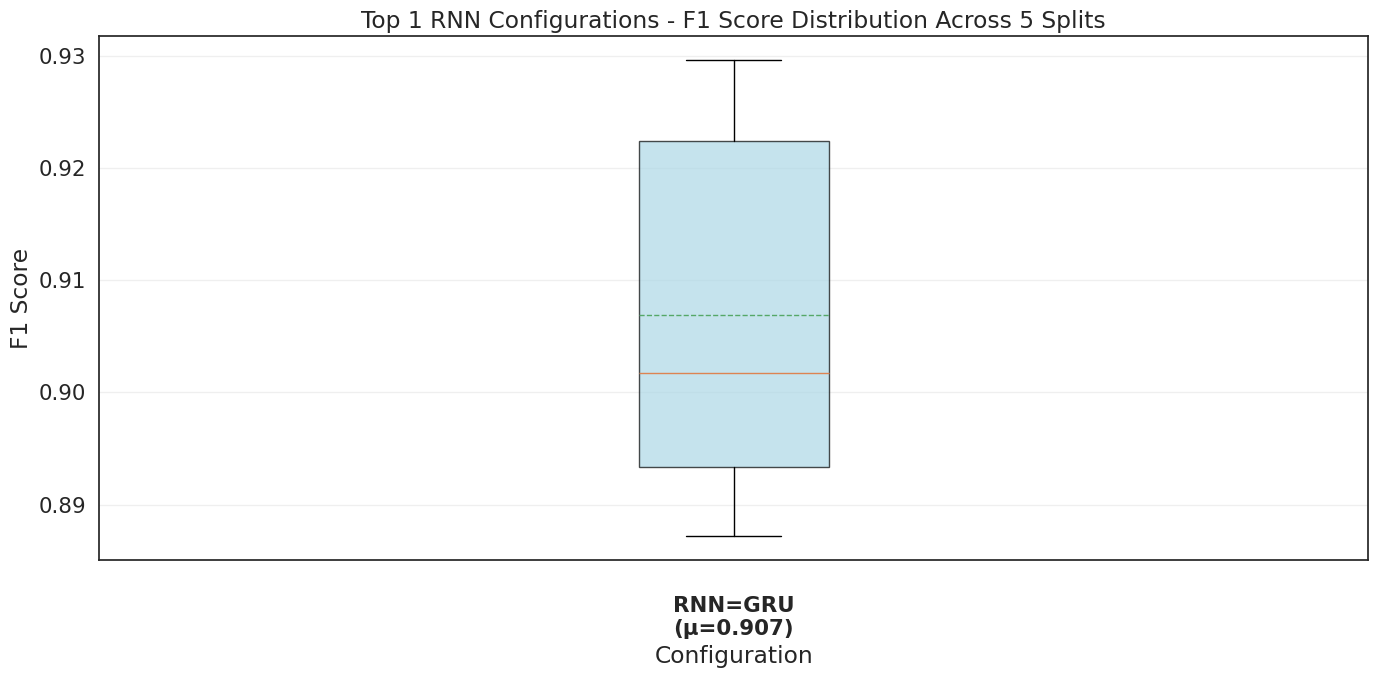

In [59]:
# Visualise results
plot_top_configurations_rnn(results, k_splits=K, top_n=5)

## **♻️ Re-Training**

In [60]:
%%time
# --- 1. Combine fixed and best hyperparameters ---
# 'fixed_params' and 'best_config' are loaded from the grid search cell
final_best_params = {**fixed_params, **best_config}

# Generate config string (from grid params only) to find saved model files
best_config_str = "_".join([f"{k}_{v}" for k, v in best_config.items()])


# --- 2. Setup criterion and optimizer ---
from sklearn.utils.class_weight import compute_class_weight

classes=np.unique(y_re_train)
weights=compute_class_weight(class_weight='balanced',classes=classes,y=y_re_train)
weights=torch.tensor(weights,dtype=torch.float).to(device)

# Set up loss function and optimizer
criterion = FocalLoss(alpha=weights, gamma=2.0)



# --- 3. Initialise the Model ---
# Use the best architecture parameters from the grid search
model = RecurrentClassifier(
  input_size=input_re_shape[-1], # num_features (3)
  hidden_size=final_best_params['hidden_size'],
  num_layers=final_best_params['hidden_layers'],
  num_classes=len(label_mapping), # num_classes (6)
  dropout_rate=final_best_params['dropout_rate'],
  bidirectional=final_best_params['bidirectional'],
  rnn_type=final_best_params['rnn_type']
).to(device)

# --- 4. Load best weights from k-fold cv ---
best_fold_model_path = f"models/{best_config_str}/split_{idx_max}_model.pt"

try:
    print(f"Loading weights from best fold: {best_fold_model_path}")
    model.load_state_dict(torch.load(best_fold_model_path, map_location=device))
    print("Pre-trained weights loaded successfully!")
    starting_from_scratch = False
except FileNotFoundError:
    print(f"Model file not found at {best_fold_model_path}")
    print("Starting training from scratch")
    starting_from_scratch = True

# --- 5. Setup TensorBoard ---
experiment_name = "rnn"   #rnn, lstm or gru
writer = SummaryWriter("./"+logs_dir+"/"+experiment_name)
x = torch.randn(1, input_shape[0], input_shape[1]).to(device)
writer.add_graph(model, x)

# Define optimizer with L2 regularization
optimizer = torch.optim.AdamW(model.parameters(), lr=final_best_params['learning_rate']*0.1, weight_decay=final_best_params['l2_lambda'])

# Enable mixed precision training for GPU acceleration
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))



Loading weights from best fold: models/rnn_type_GRU/split_0_model.pt
Pre-trained weights loaded successfully!
CPU times: user 60.7 ms, sys: 3.72 ms, total: 64.4 ms
Wall time: 705 ms


In [61]:
%%time
# Train model and track training history
model, training_history = fit(
    model=model,
    train_loader=re_train_loader,
    val_loader=re_val_loader,
    epochs=EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    writer=writer,
    verbose=1,
    experiment_name="rnn",
    patience=PATIENCE
    )

# Update best model if current performance is superior
if training_history['val_f1'][-1] > best_performance:
    best_model = model
    best_performance = training_history['val_f1'][-1]

Training 500 epochs...
Epoch   1/500 | Train: Loss=0.1571, F1 Score=0.9009 | Val: Loss=0.6599, F1 Score=0.8797
Epoch   2/500 | Train: Loss=0.0067, F1 Score=0.9676 | Val: Loss=0.6506, F1 Score=0.8881
Epoch   3/500 | Train: Loss=0.0050, F1 Score=0.9734 | Val: Loss=0.6611, F1 Score=0.8869
Epoch   4/500 | Train: Loss=0.0042, F1 Score=0.9734 | Val: Loss=0.7061, F1 Score=0.8983
Epoch   5/500 | Train: Loss=0.0041, F1 Score=0.9764 | Val: Loss=0.6578, F1 Score=0.8934
Epoch   6/500 | Train: Loss=0.0036, F1 Score=0.9791 | Val: Loss=0.6954, F1 Score=0.9059
Epoch   7/500 | Train: Loss=0.0037, F1 Score=0.9808 | Val: Loss=0.7921, F1 Score=0.9065
Epoch   8/500 | Train: Loss=0.0033, F1 Score=0.9826 | Val: Loss=0.7454, F1 Score=0.8935
Epoch   9/500 | Train: Loss=0.0031, F1 Score=0.9843 | Val: Loss=0.8104, F1 Score=0.8915
Epoch  10/500 | Train: Loss=0.0030, F1 Score=0.9834 | Val: Loss=0.8201, F1 Score=0.8999
Epoch  11/500 | Train: Loss=0.0028, F1 Score=0.9856 | Val: Loss=0.7429, F1 Score=0.9033
Epoch  12

Accuracy over the validation set: 0.9285
Precision over the validation set: 0.9286
Recall over the validation set: 0.9285
F1 score over the validation set: 0.9276


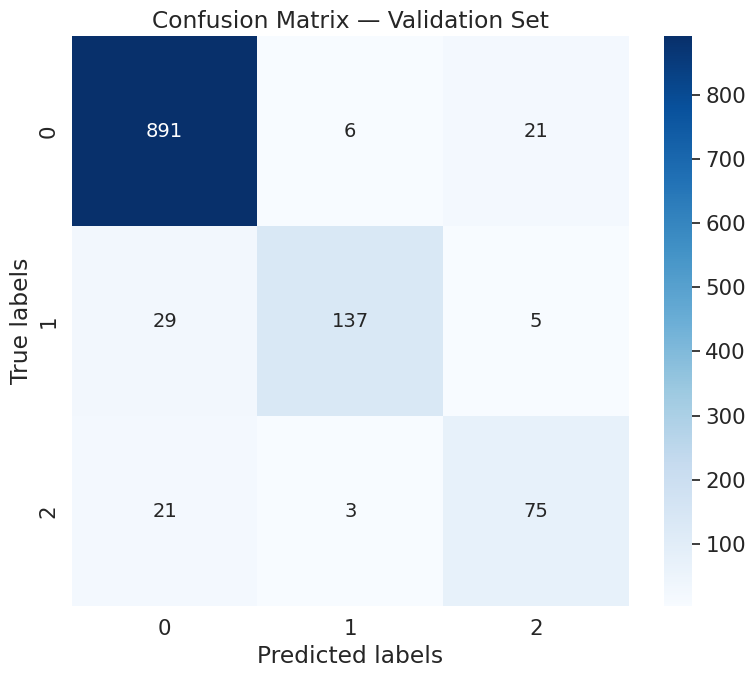

In [62]:
# @title Plot Confusion Matrix
# Collect predictions and ground truth labels
val_preds, val_targets = [], []
with torch.no_grad():  # Disable gradient computation for inference
    for xb, yb in val_loader:
        xb = xb.to(device)

        # Forward pass: get model predictions
        logits = rnn_model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()

        # Store batch results
        val_preds.append(preds)
        val_targets.append(yb.numpy())

# Combine all batches into single arrays
val_preds = np.concatenate(val_preds)
val_targets = np.concatenate(val_targets)

# Calculate overall validation metrics
val_acc = accuracy_score(val_targets, val_preds)
val_prec = precision_score(val_targets, val_preds, average='weighted')
val_rec = recall_score(val_targets, val_preds, average='weighted')
val_f1 = f1_score(val_targets, val_preds, average='weighted')
print(f"Accuracy over the validation set: {val_acc:.4f}")
print(f"Precision over the validation set: {val_prec:.4f}")
print(f"Recall over the validation set: {val_rec:.4f}")
print(f"F1 score over the validation set: {val_f1:.4f}")

# Generate confusion matrix for detailed error analysis
cm = confusion_matrix(val_targets, val_preds)

# Create numeric labels for heatmap annotation
labels = np.array([f"{num}" for num in cm.flatten()]).reshape(cm.shape)

# Visualise confusion matrix
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=labels, fmt='',
            cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix — Validation Set')
plt.tight_layout()
plt.show()

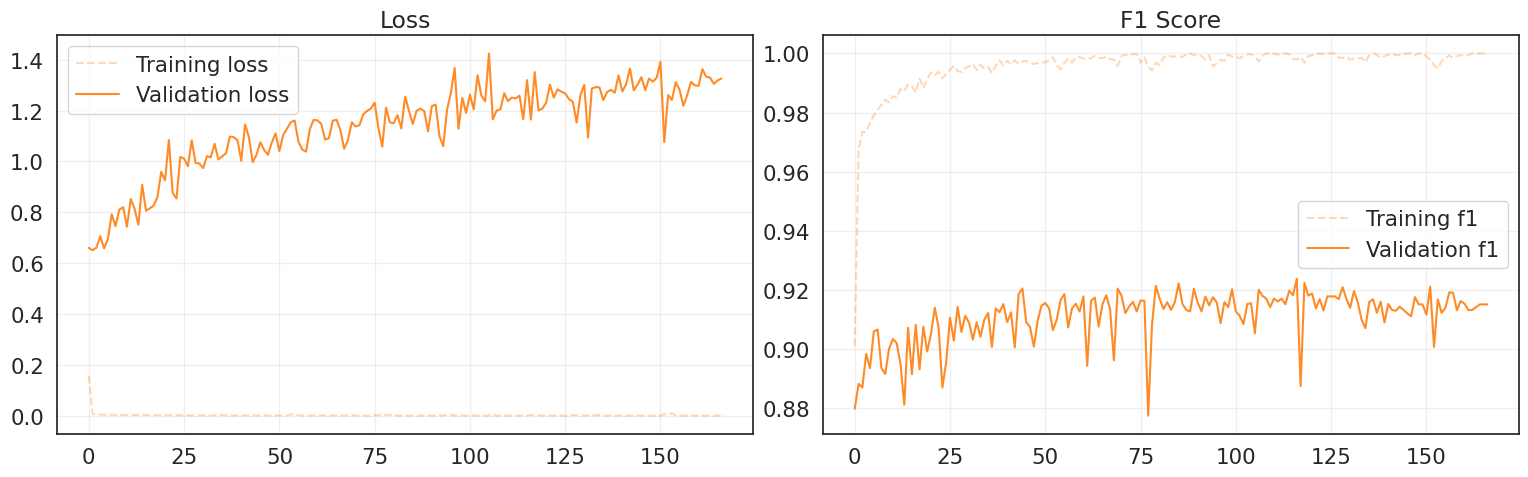

In [63]:
# @title Plot History
# Create a figure with two side-by-side subplots (two columns)
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Plot of training and validation loss on the first axis
ax1.plot(training_history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(training_history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot of training and validation accuracy on the second axis
ax2.plot(training_history['train_f1'], label='Training f1', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(training_history['val_f1'], label='Validation f1', alpha=0.9, color='#ff7f0e')
ax2.set_title('F1 Score')
ax2.legend()
ax2.grid(alpha=0.3)

# Adjust the layout and display the plot
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

## **Test**

windowing => more than one prediction per subject

solution => compute the average of the prediction probabilities and take the argmax

In [65]:
# Collect predictions and probabilities
test_preds = []
test_probs = []

with torch.no_grad():
    for (xb,) in test_loader:
        xb = xb.to(device)

        # Forward pass
        logits = best_model(xb)
        probs = torch.softmax(logits, dim=1)
        preds = logits.argmax(dim=1).cpu().numpy()

        # Store batch results
        test_preds.append(preds)
        test_probs.append(probs.cpu().numpy())

# Combine all batches
test_preds = np.concatenate(test_preds)
test_probs = np.concatenate(test_probs)

print(f"Shape probabilità: {test_probs.shape}")

# windows per subject
n_windows = ((160 -  WINDOW_SIZE) // STRIDE )  + 1

# reshape probs into (n_subjects, n_windows, n_classes)
probs_reshaped = test_probs.reshape(-1, n_windows, 3)

# average probability
avg_probs_per_subject = probs_reshaped.mean(axis=1)

# final prediction --> argmax(probs)
preds_per_subject = avg_probs_per_subject.argmax(axis=1)

print(f"Predictions per subject shape: {preds_per_subject.shape}")

# Map labels
pain_mapping = {0: "no_pain", 1: "low_pain", 2: "high_pain"}
pred_labels = [pain_mapping[p] for p in preds_per_subject]

# Submission
submission = pd.DataFrame({
    "sample_index": np.arange(len(pred_labels)),
    "Predicted": pred_labels
})

submission.head()

Shape probabilità: (11916, 3)
Predictions per subject shape: (1324,)


,sample_index,Predicted
0,0,no_pain
1,1,no_pain
2,2,no_pain
3,3,no_pain
4,4,no_pain


In [66]:
submission.to_csv("/gdrive/My Drive/[2025-2026] AN2DL/Challenge 1/submission.csv", index=False)